# Visualizing Data with Stacked Charts

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook uses stacked bar charts and area charts to visualize composition and comparison of multiple variables across categories, revealing patterns in job satisfaction, compensation, and technology preferences.

## Importing Libraries

I'll import the necessary libraries for data analysis and visualization.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Loading the Dataset

I'll download and load the survey data.

In [5]:
# Download the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

In [6]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: (65437, 114)

Column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWor

In [7]:
# Display first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Task 1: Composition of Job Satisfaction Across Age Groups

### Stacked Chart 1: Job Satisfaction Points by Age Group

I'll create a stacked bar chart showing job satisfaction scores across different age groups.

Job satisfaction columns found: ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11']


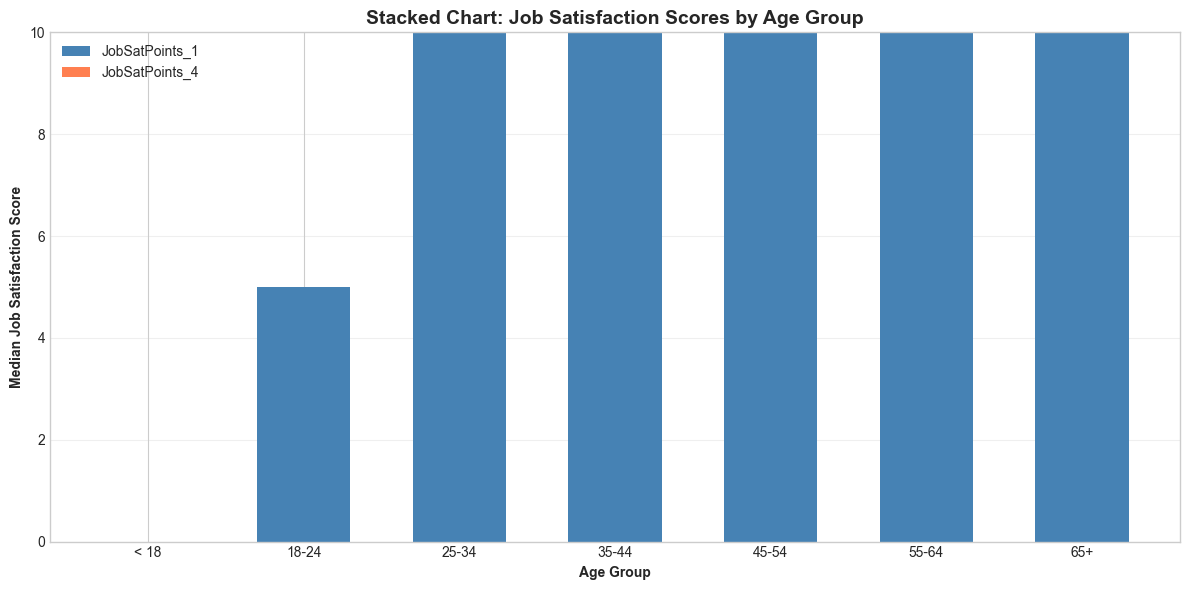

In [8]:
# Map age to numeric values
age_mapping = {
    'Under 18 years old': '< 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'
}

df['Age_Group'] = df['Age'].map(age_mapping)

# Find job satisfaction columns
jobsat_cols = [col for col in df.columns if 'JobSat' in col and 'Points' in col]
if not jobsat_cols:
    jobsat_cols = ['JobSat']  # fallback

print(f"Job satisfaction columns found: {jobsat_cols}")

# Use first two if available
if len(jobsat_cols) >= 2:
    col1, col2 = jobsat_cols[0], jobsat_cols[1]
else:
    col1 = jobsat_cols[0] if jobsat_cols else 'JobSat'
    col2 = None

# Prepare data
age_order = ['< 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_groups_present = [ag for ag in age_order if ag in df['Age_Group'].unique()]

if col2:
    # Calculate median for both columns
    sat_data = df.groupby('Age_Group')[[col1, col2]].median().reindex(age_groups_present)
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(age_groups_present))
    width = 0.6
    
    p1 = ax.bar(x, sat_data[col1], width, label=col1, color='steelblue')
    p2 = ax.bar(x, sat_data[col2], width, bottom=sat_data[col1], label=col2, color='coral')
    
    ax.set_xlabel('Age Group', fontweight='bold')
    ax.set_ylabel('Median Job Satisfaction Score', fontweight='bold')
    ax.set_title('Stacked Chart: Job Satisfaction Scores by Age Group', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(age_groups_present)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("Using single satisfaction column")
    # Map categorical to numeric
    sat_mapping = {
        'Very satisfied': 5,
        'Slightly satisfied': 4,
        'Neither satisfied nor dissatisfied': 3,
        'Slightly dissatisfied': 2,
        'Very dissatisfied': 1
    }
    df['JobSat_Numeric'] = df[col1].map(sat_mapping)
    
    # Count satisfaction levels by age
    sat_counts = df.groupby(['Age_Group', col1]).size().unstack(fill_value=0)
    sat_counts = sat_counts.reindex(age_groups_present)
    
    # Create stacked bar chart
    sat_counts.plot(kind='bar', stacked=True, figsize=(12, 6), 
                   colormap='viridis', edgecolor='black')
    plt.title('Stacked Chart: Job Satisfaction Distribution by Age Group', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Age Group', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

### Stacked Chart 2: Job Satisfaction by Employment Status

I'll compare job satisfaction across different employment types.

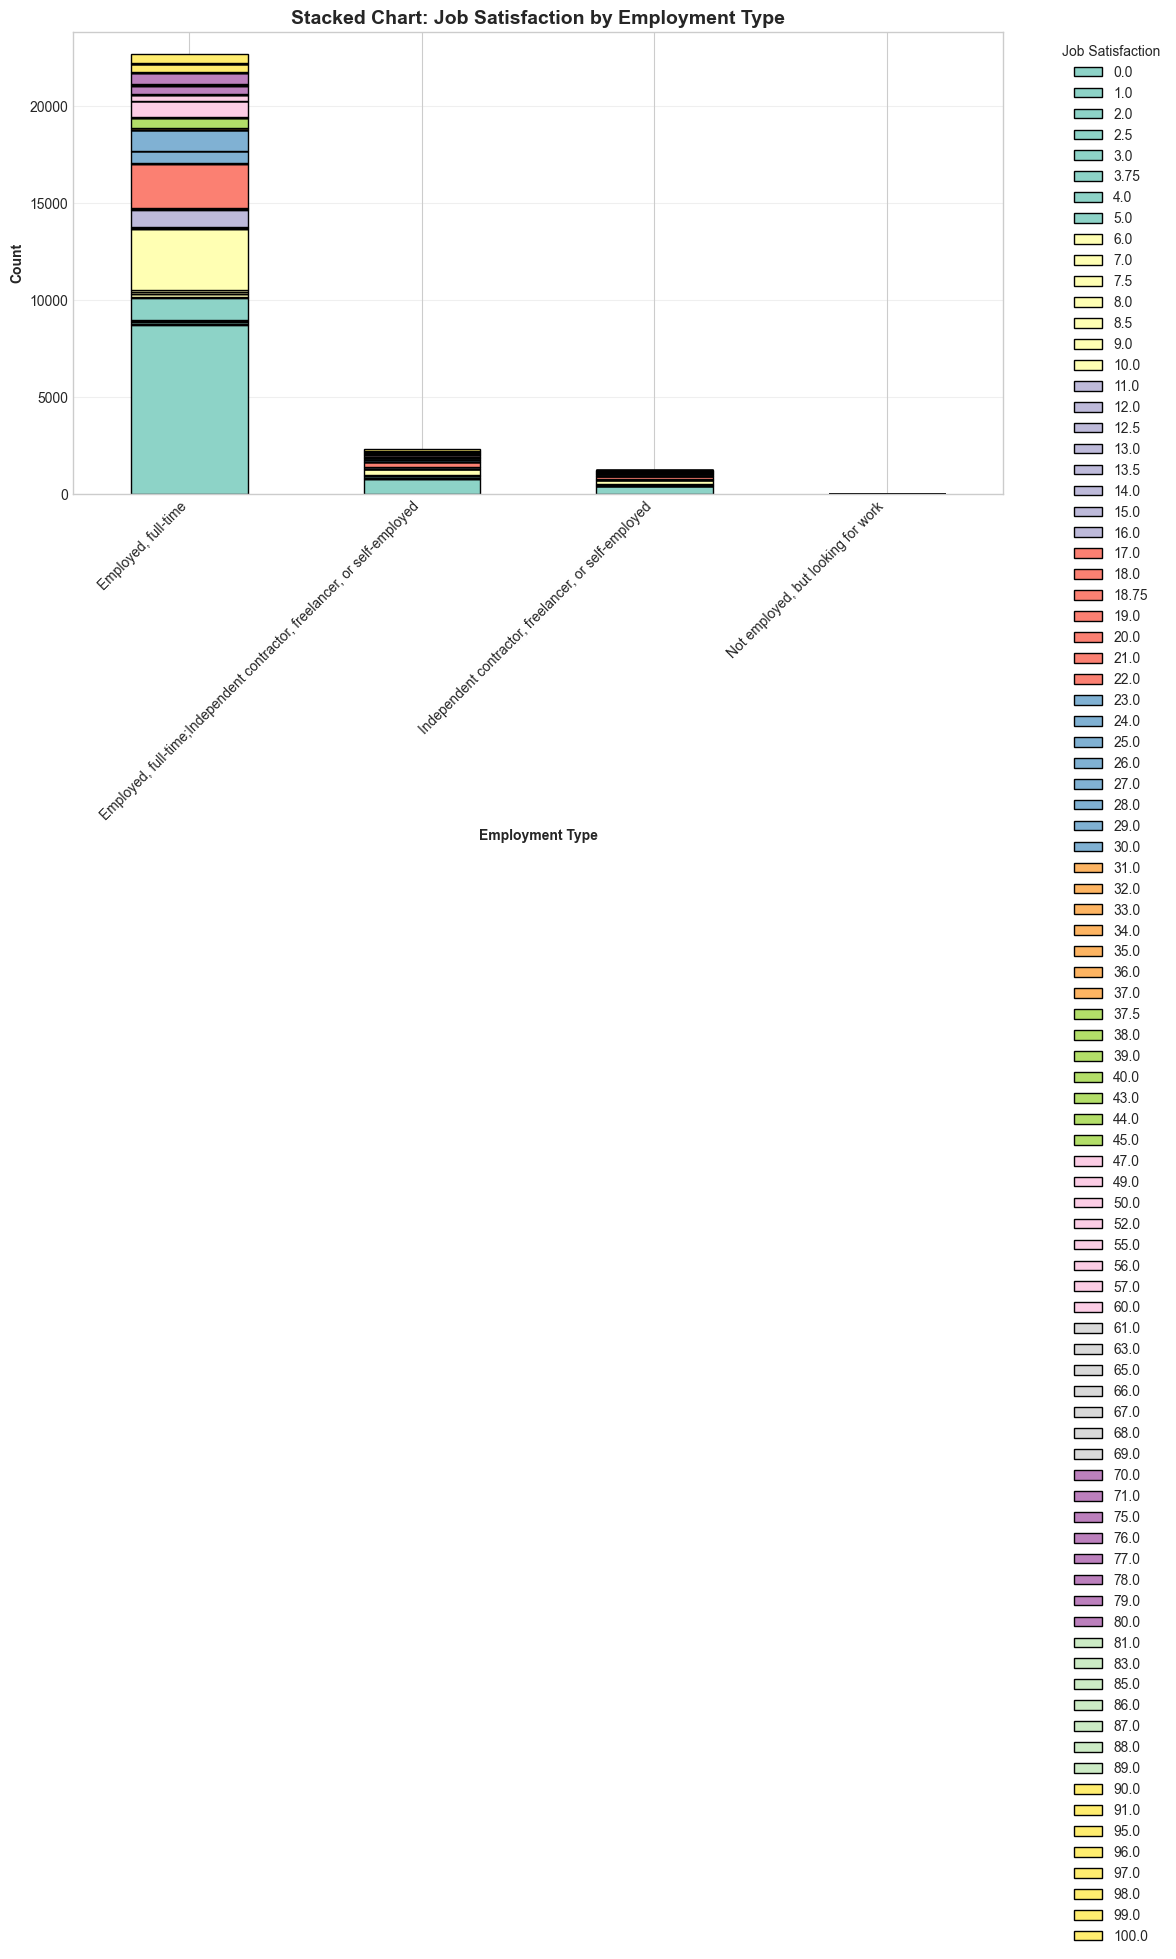

In [9]:
# Check for employment column
if 'Employment' in df.columns:
    # Get top 5 employment types
    top_employment = df['Employment'].value_counts().head(5).index
    
    # Filter data
    emp_data = df[df['Employment'].isin(top_employment)]
    
    # Count satisfaction levels by employment
    sat_col = col1
    emp_sat_counts = emp_data.groupby(['Employment', sat_col]).size().unstack(fill_value=0)
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    emp_sat_counts.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='black')
    
    ax.set_title('Stacked Chart: Job Satisfaction by Employment Type', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Employment Type', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("Employment column not found")

## Task 2: Compensation and Job Satisfaction by Age Group

### Stacked Chart 3: Compensation and Satisfaction for Ages 30-35

I'll visualize compensation and satisfaction for a specific age range.

In [10]:
# Filter for 25-34 age group (closest to 30-35)
age_30_35 = df[df['Age_Group'] == '25-34'].copy()

if len(age_30_35) > 0:
    # Prepare compensation data
    age_30_35['ConvertedCompYearly'] = pd.to_numeric(age_30_35['ConvertedCompYearly'], errors='coerce')
    age_30_35 = age_30_35.dropna(subset=['ConvertedCompYearly', sat_col])
    
    # Group by satisfaction and calculate median compensation
    comp_by_sat = age_30_35.groupby(sat_col)['ConvertedCompYearly'].agg(['median', 'count'])
    comp_by_sat = comp_by_sat[comp_by_sat['count'] >= 5]  # Filter small groups
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(comp_by_sat))
    ax.bar(x, comp_by_sat['median'], color='teal', edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Job Satisfaction Level', fontweight='bold')
    ax.set_ylabel('Median Yearly Compensation ($)', fontweight='bold')
    ax.set_title('Bar Chart: Compensation by Job Satisfaction Level (Age 25-34)', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comp_by_sat.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    print(f"\nMedian compensation by satisfaction (Age 25-34):")
    print(comp_by_sat)
else:
    print("No data found for age group 25-34")

### Stacked Chart 4: Median Compensation and Satisfaction Across All Age Groups

I'll create a comprehensive comparison across all age groups.

In [11]:
# Prepare data
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# sat_col (JobSatPoints_1) is already numeric (0-8 scale); use it directly
sat_numeric = sat_col

# Group by age and calculate medians
age_stats = df.groupby('Age_Group').agg({
    'ConvertedCompYearly': 'median',
    sat_numeric: 'median'
}).reindex(age_groups_present)

# Normalize for stacked visualization
# Scale compensation to similar range as satisfaction
age_stats['Comp_Scaled'] = age_stats['ConvertedCompYearly'] / 10000

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(age_groups_present))
width = 0.6

p1 = ax.bar(x, age_stats[sat_numeric], width, label='Median Satisfaction Score', 
           color='lightblue', edgecolor='black')
p2 = ax.bar(x, age_stats['Comp_Scaled'], width, bottom=age_stats[sat_numeric], 
           label='Compensation (scaled)', color='lightcoral', edgecolor='black')

ax.set_xlabel('Age Group', fontweight='bold')
ax.set_ylabel('Stacked Values', fontweight='bold')
ax.set_title('Stacked Chart: Median Compensation & Satisfaction by Age Group', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(age_groups_present)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nMedian values by age group:")
print(age_stats[['ConvertedCompYearly', sat_numeric]])

## Task 3: Comparing Data Using Stacked Charts

### Stacked Chart 5: Preferred Databases by Age Group

I'll visualize database preferences across different age groups.

In [ ]:
# Check for database column
if 'DatabaseWantToWorkWith' in df.columns:
    # Prepare data
    db_age = df[['DatabaseWantToWorkWith', 'Age_Group']].dropna()
    
    # Split databases and explode
    db_age_exploded = db_age.copy()
    db_age_exploded['DatabaseWantToWorkWith'] = db_age_exploded['DatabaseWantToWorkWith'].str.split(';')
    db_age_exploded = db_age_exploded.explode('DatabaseWantToWorkWith')
    
    # Get top 5 databases
    top_dbs = db_age_exploded['DatabaseWantToWorkWith'].value_counts().head(5).index
    
    # Filter and create crosstab
    db_filtered = db_age_exploded[db_age_exploded['DatabaseWantToWorkWith'].isin(top_dbs)]
    db_age_counts = pd.crosstab(db_filtered['Age_Group'], db_filtered['DatabaseWantToWorkWith'])
    db_age_counts = db_age_counts.reindex(age_groups_present)
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    db_age_counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='black')
    
    ax.set_title('Stacked Chart: Database Preferences by Age Group', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Age Group', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("DatabaseWantToWorkWith column not found")

### Stacked Chart 6: Employment Type by Job Satisfaction

I'll analyze employment type distribution within satisfaction levels.

In [ ]:
# Check for employment column
if 'Employment' in df.columns:
    # Get top 4 employment types
    top_employment = df['Employment'].value_counts().head(4).index
    
    # Create crosstab
    emp_sat = df[df['Employment'].isin(top_employment)]
    emp_sat_crosstab = pd.crosstab(emp_sat[sat_col], emp_sat['Employment'])
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    emp_sat_crosstab.plot(kind='bar', stacked=True, ax=ax, 
                         colormap='Pastel1', edgecolor='black')
    
    ax.set_title('Stacked Chart: Employment Type Distribution by Job Satisfaction', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Job Satisfaction Level', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("Employment column not found")

## Task 4: Exploring Technology Preferences

### Stacked Chart 7: Programming Language Preferences by Age Group

I'll visualize how language preferences vary across age groups.

In [ ]:
# Check for admired languages column
lang_col = None
for col in ['LanguageAdmired', 'LanguageWantToWorkWith', 'LanguageHaveWorkedWith']:
    if col in df.columns:
        lang_col = col
        break

if lang_col:
    # Prepare data
    lang_age = df[[lang_col, 'Age_Group']].dropna()
    
    # Split languages and explode
    lang_age_exploded = lang_age.copy()
    lang_age_exploded[lang_col] = lang_age_exploded[lang_col].str.split(';')
    lang_age_exploded = lang_age_exploded.explode(lang_col)
    
    # Get top 6 languages
    top_langs = lang_age_exploded[lang_col].value_counts().head(6).index
    
    # Filter and create crosstab
    lang_filtered = lang_age_exploded[lang_age_exploded[lang_col].isin(top_langs)]
    lang_age_counts = pd.crosstab(lang_filtered['Age_Group'], lang_filtered[lang_col])
    lang_age_counts = lang_age_counts.reindex(age_groups_present)
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    lang_age_counts.plot(kind='bar', stacked=True, ax=ax, 
                        colormap='Set2', edgecolor='black')
    
    ax.set_title('Stacked Chart: Programming Language Preferences by Age Group', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Age Group', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("Language preference column not found")

### Stacked Chart 8: Platform Adoption by Employment Type

I'll explore platform preferences across different employment types.

In [ ]:
# Check for platform column
platform_col = None
for col in ['PlatformAdmired', 'PlatformWantToWorkWith', 'PlatformHaveWorkedWith']:
    if col in df.columns:
        platform_col = col
        break

if platform_col and 'Employment' in df.columns:
    # Get top 3 employment types
    top_emp = df['Employment'].value_counts().head(3).index
    
    # Prepare data
    plat_emp = df[[platform_col, 'Employment']].dropna()
    plat_emp = plat_emp[plat_emp['Employment'].isin(top_emp)]
    
    # Split platforms and explode
    plat_emp_exploded = plat_emp.copy()
    plat_emp_exploded[platform_col] = plat_emp_exploded[platform_col].str.split(';')
    plat_emp_exploded = plat_emp_exploded.explode(platform_col)
    
    # Get top 5 platforms
    top_platforms = plat_emp_exploded[platform_col].value_counts().head(5).index
    
    # Filter and create crosstab
    plat_filtered = plat_emp_exploded[plat_emp_exploded[platform_col].isin(top_platforms)]
    plat_emp_counts = pd.crosstab(plat_filtered['Employment'], plat_filtered[platform_col])
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    plat_emp_counts.plot(kind='bar', stacked=True, ax=ax, 
                        colormap='tab20', edgecolor='black')
    
    ax.set_title('Stacked Chart: Platform Adoption by Employment Type', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Employment Type', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("Platform or Employment column not found - creating alternative visualization")
    # Alternative: Web frameworks by employment
    if 'WebframeWantToWorkWith' in df.columns and 'Employment' in df.columns:
        top_emp = df['Employment'].value_counts().head(3).index
        frame_emp = df[['WebframeWantToWorkWith', 'Employment']].dropna()
        frame_emp = frame_emp[frame_emp['Employment'].isin(top_emp)]
        
        frame_emp_exploded = frame_emp.copy()
        frame_emp_exploded['WebframeWantToWorkWith'] = frame_emp_exploded['WebframeWantToWorkWith'].str.split(';')
        frame_emp_exploded = frame_emp_exploded.explode('WebframeWantToWorkWith')
        
        top_frames = frame_emp_exploded['WebframeWantToWorkWith'].value_counts().head(5).index
        frame_filtered = frame_emp_exploded[frame_emp_exploded['WebframeWantToWorkWith'].isin(top_frames)]
        frame_emp_counts = pd.crosstab(frame_filtered['Employment'], frame_filtered['WebframeWantToWorkWith'])
        
        frame_emp_counts.plot(kind='bar', stacked=True, figsize=(12, 6), 
                            colormap='Accent', edgecolor='black')
        plt.title('Stacked Chart: Web Framework Preferences by Employment Type', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Employment Type', fontweight='bold')
        plt.ylabel('Count', fontweight='bold')
        plt.legend(title='Web Framework', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

## Summary

In this notebook, I created 8 stacked charts to analyze composition and comparison in the developer survey data:

**Task 1: Job Satisfaction Composition**
- Stacked chart of satisfaction scores by age group
- Satisfaction distribution by employment type

**Task 2: Compensation & Satisfaction Analysis**
- Compensation by satisfaction for ages 25-34
- Median compensation and satisfaction across all age groups

**Task 3: Comparative Analysis**
- Database preferences by age group
- Employment type distribution by satisfaction level

**Task 4: Technology Preferences**
- Programming language preferences by age
- Platform/framework adoption by employment type

### When to Use Stacked Charts:

Stacked charts are ideal for:
- **Showing composition** - How parts make up a whole
- **Comparing totals** - See both individual and total values
- **Tracking trends** - Changes in composition over categories
- **Multi-category analysis** - Multiple variables in one view

### Advantages:
- Visual representation of part-to-whole relationships
- Easy comparison of total values across categories
- Effective for showing distribution patterns

### Considerations:
- Best with 5-7 categories for clarity
- Can be difficult to compare middle segments
- Works well with categorical data

These stacked charts revealed patterns in job satisfaction, compensation trends, technology preferences, and demographic distributions within the developer community.